# Selected Surface Diagnostics

This notebook summarizes the surface-level diagnostics used to interpret common predictive deterioration across the four main evaluation windows.

The focused outputs are the candidate-driver screen and the two ATM time-series plots used in the thesis.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [10]:
def find_project_root(start=None):
    here = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and notebooks/.")


def project_relative(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


PROJECT_ROOT = find_project_root()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUTS_DIR / "nonoverlap_q160_eval300" / "_comparison" / "tables"
PRICE_CACHE = TABLE_DIR / "nonoverlap_price_metrics_by_timestamp.csv"
LEGACY_PRICE_CACHE = TABLE_DIR / "nonoverlap_w0_400_price_metrics_by_timestamp.csv"

FIGURE_DIR = OUTPUTS_DIR / "nonoverlap_q160_eval300" / "_comparison" / "figures" / "surface_diagnostics_all_windows"
OUT_TABLE_DIR = TABLE_DIR / "surface_diagnostics_all_windows"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

WINDOWS = ["w0_400", "w401_800", "w801_1200", "w1201_1600"]
WINDOW_LABELS = {
    "w0_400": "0-399",
    "w401_800": "400-799",
    "w801_1200": "800-1199",
    "w1201_1600": "1200-1599",
}
SEEDS = [123, 456, 789, 101112, 131415]
WING_THRESHOLD = 0.20
ATM_BAND = 0.03
WING_BAND = (0.10, 0.25)
HAC_LAG = 5
MODEL_LABEL_MAP = {
    "Normal": "Markovian",
    "Markovian SABR": "Markovian",
    "Rough": "Rough-SABR",
}


def normalize_model_labels(df):
    if "model" in df.columns:
        df["model"] = df["model"].replace(MODEL_LABEL_MAP)
    return df

## Load Scores, Price Errors, and q300 Panel Features

In [11]:
scores_raw = pd.read_csv(TABLE_DIR / "nonoverlap_timestamp_scores_eval.csv")
scores_raw = scores_raw[scores_raw["window"].isin(WINDOWS)].copy()
scores_raw = normalize_model_labels(scores_raw)

score_paths = (
    scores_raw.groupby(["window", "model", "t_index"], as_index=False)
    .agg(
        capture_time_utc=("capture_time_utc", "first"),
        log_score=("log_predictive_likelihood", "mean"),
        avg_log_score_per_quote=("avg_log_predictive_likelihood_per_quote", "mean"),
        n_eval_quotes=("eval_n_options", "mean"),
    )
)
score_paths["relative_t"] = score_paths["t_index"] - score_paths.groupby("window")["t_index"].transform("min")

score_wide = score_paths.pivot(index=["window", "t_index", "relative_t"], columns="model", values="log_score").reset_index()
score_wide_avg = score_paths.pivot(index=["window", "t_index", "relative_t"], columns="model", values="avg_log_score_per_quote").reset_index()
score_wide = score_wide.rename(columns={"Rough": "rough_score", "Rough-SABR": "rough_score", "Normal": "normal_score", "Markovian": "normal_score"})
score_wide_avg = score_wide_avg.rename(columns={"Rough": "rough_avg_score", "Rough-SABR": "rough_avg_score", "Normal": "normal_avg_score", "Markovian": "normal_avg_score"})
score_diag = score_wide.merge(score_wide_avg, on=["window", "t_index", "relative_t"], how="left")
score_diag["score_diff_rough_minus_normal"] = score_diag["rough_score"] - score_diag["normal_score"]
score_diag["common_score_deterioration"] = -0.5 * (score_diag["rough_avg_score"] + score_diag["normal_avg_score"])

price_metrics_path = PRICE_CACHE if PRICE_CACHE.exists() else LEGACY_PRICE_CACHE
price_metrics = pd.read_csv(price_metrics_path)
price_metrics = price_metrics[price_metrics["window"].isin(WINDOWS)].copy()
price_metrics = normalize_model_labels(price_metrics)
price_avg = (
    price_metrics.groupby(["window", "model", "t_index"], as_index=False)
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        inside_bidask_rate=("inside_bidask_rate", "mean"),
        mean_price_sd=("mean_price_sd", "mean"),
        invalid_prediction_rate=("invalid_prediction_rate", "mean"),
    )
)
price_wide = price_avg.pivot(index=["window", "t_index"], columns="model", values=["rmse", "mae", "inside_bidask_rate", "mean_price_sd"]).reset_index()
price_wide.columns = ["_".join([str(x) for x in col if str(x) != ""]).strip("_") for col in price_wide.columns]
price_wide = price_wide.rename(
    columns={
        "rmse_Rough": "rmse_rough",
        "rmse_Rough-SABR": "rmse_rough",
        "rmse_Normal": "rmse_normal",
        "rmse_Markovian": "rmse_normal",
        "mae_Rough": "mae_rough",
        "mae_Rough-SABR": "mae_rough",
        "mae_Normal": "mae_normal",
        "mae_Markovian": "mae_normal",
        "inside_bidask_rate_Rough": "inside_bidask_rough",
        "inside_bidask_rate_Rough-SABR": "inside_bidask_rough",
        "inside_bidask_rate_Normal": "inside_bidask_normal",
        "inside_bidask_rate_Markovian": "inside_bidask_normal",
        "mean_price_sd_Rough": "price_sd_rough",
        "mean_price_sd_Rough-SABR": "price_sd_rough",
        "mean_price_sd_Normal": "price_sd_normal",
        "mean_price_sd_Markovian": "price_sd_normal",
    }
)
price_wide["rmse_diff_rough_minus_normal"] = price_wide["rmse_rough"] - price_wide["rmse_normal"]
price_wide["price_sd_diff_rough_minus_normal"] = price_wide["price_sd_rough"] - price_wide["price_sd_normal"]
display(score_diag.head())

model,window,t_index,relative_t,normal_score,rough_score,normal_avg_score,rough_avg_score,score_diff_rough_minus_normal,common_score_deterioration
0,w0_400,0,0,-28.134600,-24.819765,-0.097016,-0.085585,3.314835,0.091301
1,w0_400,1,1,-25.084068,-24.787216,-0.086497,-0.085473,0.296852,0.085985
2,w0_400,2,2,-21.592464,-21.470206,-0.074457,-0.074035,0.122258,0.074246
3,w0_400,3,3,-21.634819,-20.669479,-0.074603,-0.071274,0.965339,0.072938
4,w0_400,4,4,-22.495877,-20.605033,-0.077572,-0.071052,1.890844,0.074312


In [12]:
PANEL_FILES = {
    "w0_400": OUTPUTS_DIR / "common_eval_q160_eval300" / "normal_400ts_q160_eval300_seed123" / "evaluation_observations.csv",
    "w401_800": OUTPUTS_DIR / "nonoverlap_q160_eval300" / "w401_800" / "normal_sabr_no_A_RW_seed123" / "evaluation_observations.csv",
    "w801_1200": OUTPUTS_DIR / "nonoverlap_q160_eval300" / "w801_1200" / "normal_sabr_no_A_RW_seed123" / "evaluation_observations.csv",
    "w1201_1600": OUTPUTS_DIR / "nonoverlap_q160_eval300" / "w1201_1600" / "normal_sabr_no_A_RW_seed123" / "evaluation_observations.csv",
}


def _nearest_atm_by_group(df, group_cols):
    tmp = df.dropna(subset=["market_iv_percent", "abs_log_moneyness", "maturity_days"]).copy()
    if tmp.empty:
        return pd.DataFrame(columns=group_cols + ["atm_iv_percent", "atm_maturity_days"])
    idx = tmp.groupby(group_cols)["abs_log_moneyness"].idxmin()
    out = tmp.loc[idx, group_cols + ["market_iv_percent", "maturity_days"]].copy()
    return out.rename(columns={"market_iv_percent": "atm_iv_percent", "maturity_days": "atm_maturity_days"})


def _atm_level(group):
    near = group[group["abs_log_moneyness"] <= ATM_BAND]["market_iv_percent"].dropna()
    if len(near) > 0:
        return near.median()
    nearest = group.nsmallest(min(10, len(group)), "abs_log_moneyness")["market_iv_percent"].dropna()
    return nearest.median() if len(nearest) else np.nan


def _left_wing_iv(group):
    lo, hi = WING_BAND
    wing = group[(group["log_moneyness"] <= -lo) & (group["log_moneyness"] >= -hi)]["market_iv_percent"].dropna()
    return wing.median() if len(wing) else np.nan


def _right_wing_iv(group):
    lo, hi = WING_BAND
    wing = group[(group["log_moneyness"] >= lo) & (group["log_moneyness"] <= hi)]["market_iv_percent"].dropna()
    return wing.median() if len(wing) else np.nan


def load_panel_features(window, path):
    usecols = [
        "capture_time_utc",
        "t_index",
        "expiry",
        "T_years",
        "time_to_expiry_years",
        "log_moneyness",
        "market_price",
        "bid_price",
        "ask_price",
        "F_obs",
        "market_iv",
        "mark_iv",
    ]
    df = pd.read_csv(path, usecols=lambda c: c in usecols)
    df["window"] = window
    t_years = df["T_years"] if "T_years" in df.columns else df["time_to_expiry_years"]
    df["maturity_days"] = pd.to_numeric(t_years, errors="coerce") * 365.0
    df["log_moneyness"] = pd.to_numeric(df["log_moneyness"], errors="coerce")
    df["abs_log_moneyness"] = df["log_moneyness"].abs()
    df["wing_quote"] = df["abs_log_moneyness"] > WING_THRESHOLD
    df["market_price"] = pd.to_numeric(df["market_price"], errors="coerce")
    df["bid_price"] = pd.to_numeric(df["bid_price"], errors="coerce")
    df["ask_price"] = pd.to_numeric(df["ask_price"], errors="coerce")
    df["F_obs"] = pd.to_numeric(df["F_obs"], errors="coerce")
    df["relative_bidask_width"] = (df["ask_price"] - df["bid_price"]) / df["market_price"]
    df.loc[~np.isfinite(df["relative_bidask_width"]), "relative_bidask_width"] = np.nan
    df.loc[df["relative_bidask_width"] < 0, "relative_bidask_width"] = np.nan
    if "market_iv" in df.columns:
        iv = pd.to_numeric(df["market_iv"], errors="coerce") * 100.0
    else:
        iv = pd.to_numeric(df["mark_iv"], errors="coerce")
    df["market_iv_percent"] = iv
    df.loc[(df["market_iv_percent"] <= 0) | (~np.isfinite(df["market_iv_percent"])), "market_iv_percent"] = np.nan

    composition = (
        df.groupby(["window", "t_index"], as_index=False)
        .agg(
            capture_time_utc=("capture_time_utc", "first"),
            q300_quotes=("market_price", "size"),
            n_expiries=("expiry", "nunique"),
            mean_maturity_days=("maturity_days", "mean"),
            median_maturity_days=("maturity_days", "median"),
            min_maturity_days=("maturity_days", "min"),
            max_maturity_days=("maturity_days", "max"),
            wing_quote_share=("wing_quote", "mean"),
            mean_abs_log_moneyness=("abs_log_moneyness", "mean"),
            median_relative_bidask_width=("relative_bidask_width", "median"),
            mean_relative_bidask_width=("relative_bidask_width", "mean"),
            median_market_iv_percent=("market_iv_percent", "median"),
            F_obs=("F_obs", "median"),
        )
    )

    shape_rows = []
    for (w, t), group in df.groupby(["window", "t_index"]):
        atm_iv = _atm_level(group)
        left_iv = _left_wing_iv(group)
        right_iv = _right_wing_iv(group)
        wing_avg = np.nanmean([left_iv, right_iv]) if not (pd.isna(left_iv) and pd.isna(right_iv)) else np.nan
        shape_rows.append(
            {
                "window": w,
                "t_index": t,
                "atm_iv_percent": atm_iv,
                "left_wing_iv_percent": left_iv,
                "right_wing_iv_percent": right_iv,
                "smile_skew_left_minus_right": left_iv - right_iv if pd.notna(left_iv) and pd.notna(right_iv) else np.nan,
                "smile_curvature_wings_minus_atm": wing_avg - atm_iv if pd.notna(wing_avg) and pd.notna(atm_iv) else np.nan,
            }
        )
    shape = pd.DataFrame(shape_rows)

    atm_by_expiry = _nearest_atm_by_group(df, ["window", "t_index", "expiry"])
    term_rows = []
    for (w, t), group in atm_by_expiry.groupby(["window", "t_index"]):
        g = group.dropna(subset=["atm_iv_percent", "atm_maturity_days"]).sort_values("atm_maturity_days")
        if len(g) >= 2:
            near = g.iloc[0]
            far = g.iloc[-1]
            term_rows.append(
                {
                    "window": w,
                    "t_index": t,
                    "near_atm_maturity_days": near["atm_maturity_days"],
                    "far_atm_maturity_days": far["atm_maturity_days"],
                    "near_atm_iv_percent": near["atm_iv_percent"],
                    "far_atm_iv_percent": far["atm_iv_percent"],
                    "atm_term_slope_far_minus_near": far["atm_iv_percent"] - near["atm_iv_percent"],
                }
            )
        else:
            term_rows.append(
                {
                    "window": w,
                    "t_index": t,
                    "near_atm_maturity_days": np.nan,
                    "far_atm_maturity_days": np.nan,
                    "near_atm_iv_percent": np.nan,
                    "far_atm_iv_percent": np.nan,
                    "atm_term_slope_far_minus_near": np.nan,
                }
            )
    term = pd.DataFrame(term_rows)

    out = composition.merge(shape, on=["window", "t_index"], how="left").merge(term, on=["window", "t_index"], how="left")
    out = out.sort_values("t_index")
    out["relative_t"] = out["t_index"] - out["t_index"].min()
    out["abs_forward_return_bps"] = (np.log(out["F_obs"]).diff().abs() * 10000.0).fillna(0.0)
    out["forward_return_bps"] = (np.log(out["F_obs"]).diff() * 10000.0).fillna(0.0)
    return out


panel_features = pd.concat([load_panel_features(window, path) for window, path in PANEL_FILES.items()], ignore_index=True)
display(panel_features.head())

,window,t_index,capture_time_utc,q300_quotes,n_expiries,mean_maturity_days,median_maturity_days,min_maturity_days,max_maturity_days,wing_quote_share,mean_abs_log_moneyness,median_relative_bidask_width,mean_relative_bidask_width,median_market_iv_percent,F_obs,atm_iv_percent,left_wing_iv_percent,right_wing_iv_percent,smile_skew_left_minus_right,smile_curvature_wings_minus_atm,near_atm_maturity_days,far_atm_maturity_days,near_atm_iv_percent,far_atm_iv_percent,atm_term_slope_far_minus_near,relative_t,abs_forward_return_bps,forward_return_bps
0,w0_400,0,2026-05-26T13:25:12+0000,290,7,18.468411,9.440825,1.440825,65.440825,0.168966,0.111699,0.087108,0.226762,35.915,76767.93,31.72,46.720,36.145,10.575,9.7125,1.440825,65.440825,31.02,35.29,4.27,0,0.000000,0.000000
1,w0_400,1,2026-05-26T13:30:12+0000,290,7,18.464936,9.437350,1.437350,65.437350,0.168966,0.111721,0.068148,0.153964,35.980,76752.84,31.80,46.565,36.210,10.355,9.5875,1.437350,65.437350,30.91,35.32,4.41,1,1.965858,-1.965858
2,w0_400,2,2026-05-26T13:33:28+0000,290,7,18.462675,9.435089,1.435089,65.435089,0.172414,0.111780,0.069803,0.231405,36.220,76705.32,31.94,46.560,36.260,10.300,9.4700,1.435089,65.435089,31.27,35.34,4.07,2,6.193219,-6.193219
3,w0_400,3,2026-05-26T13:38:28+0000,290,7,18.459201,9.431614,1.431614,65.431614,0.168966,0.111612,0.079591,0.167642,36.285,76844.57,32.05,46.630,36.865,9.765,9.6975,1.431614,65.431614,31.00,35.36,4.36,3,18.137432,18.137432
4,w0_400,4,2026-05-26T13:43:28+0000,290,7,18.455726,9.428139,1.428139,65.428139,0.165517,0.111561,0.064998,0.204236,36.345,76883.74,32.11,46.700,36.855,9.845,9.6675,1.428139,65.428139,30.98,35.39,4.41,4,5.096004,5.096004


## Combined Timestamp Diagnostics

In [13]:
timestamp_diag = (
    score_diag.merge(panel_features, on=["window", "t_index", "relative_t"], how="left", suffixes=("", "_panel"))
    .merge(price_wide, on=["window", "t_index"], how="left")
)
timestamp_diag.to_csv(OUT_TABLE_DIR / "all_windows_timestamp_surface_diagnostics.csv", index=False)

summary_rows = []
for window in WINDOWS:
    grp = timestamp_diag[timestamp_diag["window"] == window]
    summary_rows.append(
        {
            "Window": WINDOW_LABELS.get(window, window),
            "Mean Rough - Markovian score": grp["score_diff_rough_minus_normal"].mean(),
            "Mean common score deterioration": grp["common_score_deterioration"].mean(),
            "Mean q300 quotes": grp["q300_quotes"].mean(),
            "Mean maturity days": grp["mean_maturity_days"].mean(),
            "Mean wing quote share": grp["wing_quote_share"].mean(),
            "Mean ATM IV percent": grp["atm_iv_percent"].mean(),
            "Mean term slope pp": grp["atm_term_slope_far_minus_near"].mean(),
            "Mean Rough-SABR RMSE": grp["rmse_rough"].mean(),
            "Mean Markovian RMSE": grp["rmse_normal"].mean(),
            "Share Rough lower RMSE": (grp["rmse_diff_rough_minus_normal"] < 0).mean(),
        }
    )
summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(OUT_TABLE_DIR / "all_windows_surface_summary.csv", index=False)
display(summary_table.round(4))

,Window,Mean Rough - Markovian score,Mean common score deterioration,Mean q300 quotes,Mean maturity days,Mean wing quote share,Mean ATM IV percent,Mean term slope pp,Mean Rough-SABR RMSE,Mean Markovian RMSE,Share Rough lower RMSE
0,0-399,1.0204,0.0678,290.020,18.7409,0.1789,33.1777,2.6272,NaN,NaN,0.0000
1,400-799,7.4893,0.1225,296.535,35.0868,0.1938,34.7733,4.9339,0.0030,0.0033,0.8575
2,800-1199,6.9525,0.1654,299.265,35.1507,0.1959,30.8992,15.5345,0.0036,0.0037,0.6525
3,1200-1599,3.4504,0.1202,299.040,34.3995,0.1896,32.9531,8.0376,0.0032,0.0032,0.4850


## Candidate Driver Screen

The screen uses one-at-a-time HAC regressions of common predictive deterioration on standardized surface variables.

In [14]:
def _build_design(df, regressors, standardize=False):
    X = pd.DataFrame({"Intercept": np.ones(len(df))}, index=df.index)
    for window in WINDOWS[1:]:
        X[f"FE {WINDOW_LABELS[window]}"] = (df["window"].astype(str) == window).astype(float)
    for regressor in regressors:
        values = pd.to_numeric(df[regressor], errors="coerce").astype(float)
        if standardize:
            sd = values.std(ddof=1)
            values = (values - values.mean()) / sd if sd > 0 else values * 0.0
        X[regressor] = values
    y = pd.to_numeric(df["common_score_deterioration"], errors="coerce").astype(float)
    if standardize:
        sd = y.std(ddof=1)
        y = (y - y.mean()) / sd if sd > 0 else y * 0.0
    keep = np.isfinite(y.to_numpy()) & np.isfinite(X.to_numpy()).all(axis=1)
    return y.loc[keep].to_numpy(), X.loc[keep], df.loc[keep, "window"].astype(str).to_numpy()


def _hac_covariance(X, residuals, groups, lag=5):
    Xv = np.asarray(X, dtype=float)
    residuals = np.asarray(residuals, dtype=float)
    xtx_inv = np.linalg.pinv(Xv.T @ Xv)
    meat = np.zeros((Xv.shape[1], Xv.shape[1]))
    for group in pd.unique(groups):
        idx = np.where(groups == group)[0]
        g = Xv[idx] * residuals[idx, None]
        meat += g.T @ g
        max_lag = min(lag, len(idx) - 1)
        for ell in range(1, max_lag + 1):
            weight = 1.0 - ell / (lag + 1.0)
            gamma = g[ell:].T @ g[:-ell]
            meat += weight * (gamma + gamma.T)
    return xtx_inv @ meat @ xtx_inv


def fit_hac_regression(df, regressors, label, lag=5, standardize=False):
    y, X, groups = _build_design(df, regressors, standardize=standardize)
    beta = np.linalg.lstsq(X.to_numpy(), y, rcond=None)[0]
    fitted = X.to_numpy() @ beta
    resid = y - fitted
    cov = _hac_covariance(X, resid, groups, lag=lag)
    se = np.sqrt(np.maximum(np.diag(cov), 0.0))
    t_stat = np.divide(beta, se, out=np.full_like(beta, np.nan), where=se > 0.0)
    p_value = 2.0 * (1.0 - stats.norm.cdf(np.abs(t_stat)))
    return pd.DataFrame(
        {
            "model": label,
            "term": X.columns,
            "coef": beta,
            "hac_se": se,
            "t_stat": t_stat,
            "p_value": p_value,
            "ci_low": beta - 1.96 * se,
            "ci_high": beta + 1.96 * se,
            "n_obs": len(y),
            "hac_lag": lag,
            "standardized": standardize,
        }
    )

In [15]:
candidate_drivers = [
    ("ATM term slope", "atm_term_slope_far_minus_near"),
    ("ATM IV", "atm_iv_percent"),
    ("Skew", "smile_skew_left_minus_right"),
    ("Curvature", "smile_curvature_wings_minus_atm"),
    ("Median relative spread", "median_relative_bidask_width"),
    ("Forward move", "abs_forward_return_bps"),
    ("Mean maturity", "mean_maturity_days"),
    ("Min maturity", "min_maturity_days"),
    ("Max maturity", "max_maturity_days"),
    ("Wing quote share", "wing_quote_share"),
    ("Mean abs log-moneyness", "mean_abs_log_moneyness"),
    ("q300 quote count", "q300_quotes"),
    ("Number of expiries", "n_expiries"),
]
candidate_cols = [col for _, col in candidate_drivers]
candidate_data = timestamp_diag[["window", "relative_t", "common_score_deterioration"] + candidate_cols].replace([np.inf, -np.inf], np.nan).copy()

screen_rows = []
for label, col in candidate_drivers:
    d = candidate_data[["window", "relative_t", "common_score_deterioration", col]].dropna().copy()
    if len(d) <= HAC_LAG + 10 or d[col].std(ddof=1) == 0:
        continue
    result = fit_hac_regression(d, [col], label=label, lag=HAC_LAG, standardize=True)
    screen_rows.append(result[result["term"].eq(col)].assign(driver=label, variable=col))

candidate_screen = pd.concat(screen_rows, ignore_index=True)
candidate_screen["abs_coef"] = candidate_screen["coef"].abs()
candidate_screen = candidate_screen.sort_values("abs_coef", ascending=False).reset_index(drop=True)
candidate_screen.to_csv(OUT_TABLE_DIR / "hac_candidate_driver_screen_standardized.csv", index=False)
display(candidate_screen[["driver", "coef", "hac_se", "t_stat", "p_value", "ci_low", "ci_high", "n_obs"]].round(4))

,driver,coef,hac_se,t_stat,p_value,ci_low,ci_high,n_obs
0,ATM term slope,0.4951,0.0563,8.7971,0.0000,0.3848,0.6055,1600
1,ATM IV,-0.4889,0.0497,-9.8302,0.0000,-0.5863,-0.3914,1600
2,Max maturity,0.4843,0.0368,13.1690,0.0000,0.4123,0.5564,1600
3,Number of expiries,0.4712,0.0386,12.2215,0.0000,0.3956,0.5468,1600
4,Curvature,0.2073,0.0854,2.4260,0.0153,0.0398,0.3747,1600
5,Mean abs log-moneyness,-0.1857,0.0289,-6.4175,0.0000,-0.2424,-0.1290,1600
6,Mean maturity,0.1700,0.1078,1.5775,0.1147,-0.0412,0.3812,1600
7,Min maturity,-0.1597,0.0288,-5.5434,0.0000,-0.2161,-0.1032,1600
8,q300 quote count,0.1574,0.0410,3.8385,0.0001,0.0770,0.2378,1600
9,Skew,0.1437,0.0315,4.5629,0.0000,0.0819,0.2054,1600


## ATM Diagnostic Plots

The thesis uses these two time-series panels to show how common predictive deterioration co-moves with ATM term slope and ATM IV level.

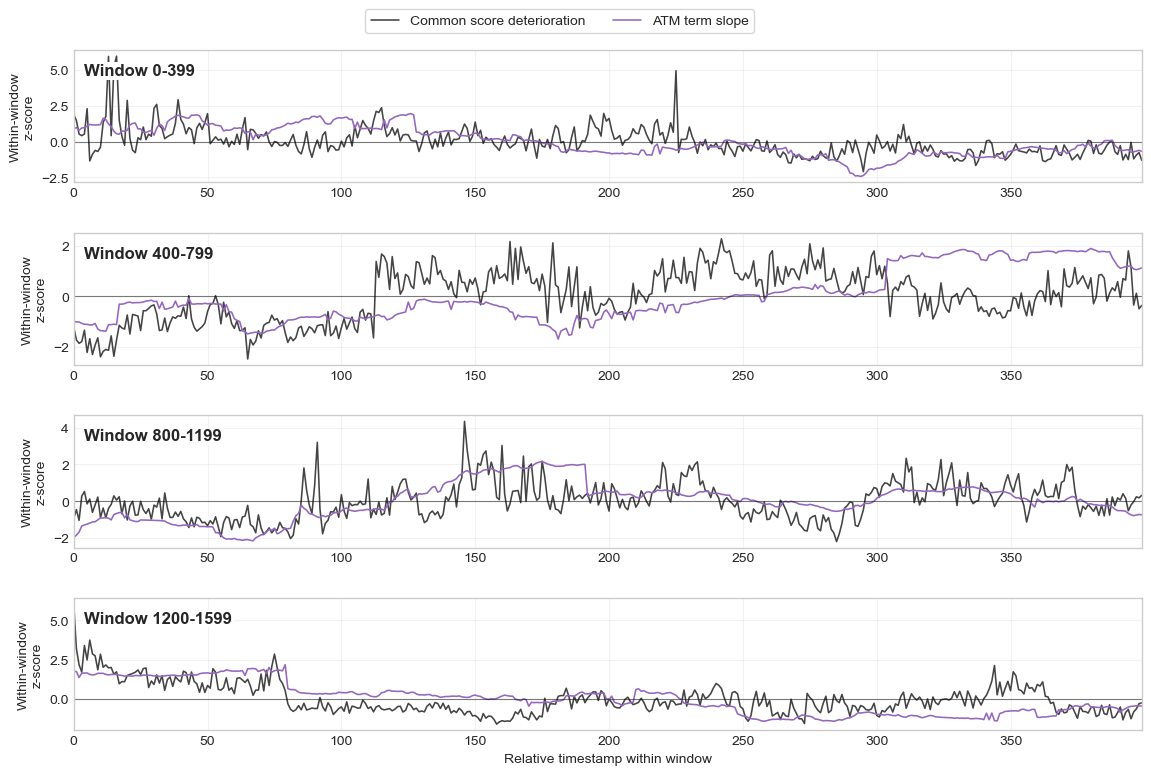

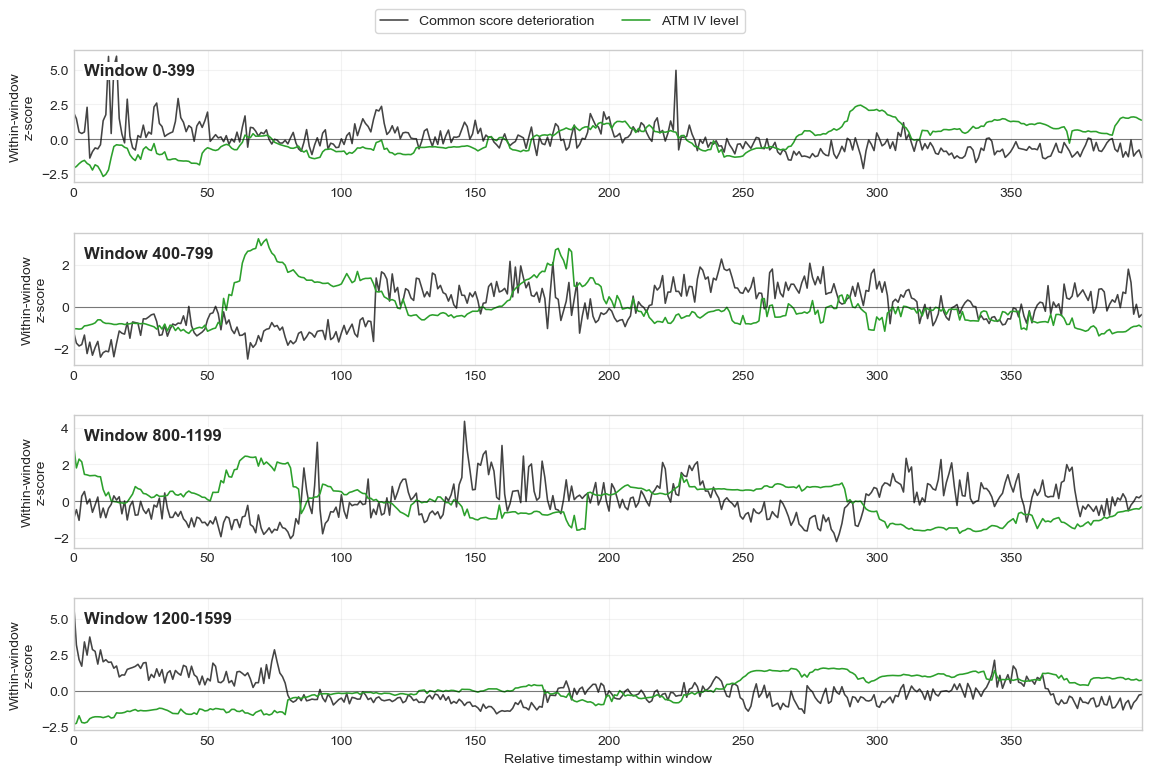

In [16]:
def zscore(values):
    values = pd.to_numeric(values, errors="coerce").astype(float)
    sd = values.std(ddof=1)
    return (values - values.mean()) / sd if sd > 0 else values * 0.0


def plot_feature_against_deterioration(feature, feature_label, color, filename):
    fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(12, 8), sharex=False)
    axes = np.atleast_1d(axes)
    for ax, window in zip(axes, WINDOWS):
        d = timestamp_diag[timestamp_diag["window"] == window].sort_values("relative_t")
        x = d["relative_t"]
        ax.plot(x, zscore(d["common_score_deterioration"]), color="#444444", lw=1.15, label="Common score deterioration")
        ax.plot(x, zscore(d[feature]), color=color, lw=1.15, label=feature_label)
        ax.axhline(0, color="black", lw=0.8, alpha=0.5)
        ax.text(
            0.01,
            0.90,
            f"Window {WINDOW_LABELS.get(window, window)}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=12,
            fontweight="bold",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0},
        )
        ax.set_xlim(0, 399)
        ax.set_ylabel("Within-window\nz-score")
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel("Relative timestamp within window")
    fig.legend(
        handles=[
            Line2D([0], [0], color="#444444", lw=1.15, label="Common score deterioration"),
            Line2D([0], [0], color=color, lw=1.15, label=feature_label),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=2,
        frameon=True,
    )
    fig.subplots_adjust(left=0.095, right=0.985, top=0.925, bottom=0.075, hspace=0.38)
    fig.savefig(FIGURE_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()


plot_feature_against_deterioration(
    "atm_term_slope_far_minus_near",
    "ATM term slope",
    "#9467bd",
    "all_windows_term_slope_vs_deterioration_timeseries.png",
)
plot_feature_against_deterioration(
    "atm_iv_percent",
    "ATM IV level",
    "#2ca02c",
    "all_windows_atm_iv_vs_deterioration_timeseries.png",
)